In [36]:
try:

    from google.colab import drive
    drive.mount('/content/drive')

except:

    print("Not running in Google Colab")


Not running in Google Colab


In [37]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import tqdm as tqdm

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [38]:
CONFIG = {
    "data_dir": r"/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color",
    "img_size": 224,
    "batch_size": 32,
    "num_epochs": 15,
    "lr": 1e-3,
    "val_split": 0.2,
    "num_workers": 2,
    "checkpoint": "best_model.pth",
    "seed": 42,
}

In [39]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [40]:
def compute_mean_std(data_dir, sample_limit=5000):
    """
    Compute per-channel mean and std from your dataset.
    Loads images as tensors [0,1] and accumulates stats.
    """
    dataset = datasets.ImageFolder(
        data_dir,
        transform=transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor()
        ])
    )
    # Limit samples for speed
    indices = torch.randperm(len(dataset))[:sample_limit]
    loader  = DataLoader(torch.utils.data.Subset(dataset, indices),
                         batch_size=64, num_workers=2)

    mean = torch.zeros(3)
    std  = torch.zeros(3)
    n    = 0

    for images, _ in loader:
        # images: [B, 3, H, W]
        b = images.size(0)
        mean += images.mean(dim=[0, 2, 3]) * b
        std  += images.std(dim=[0, 2, 3])  * b
        n    += b

    mean /= n
    std  /= n
    print(f"Dataset mean: {mean.tolist()}")
    print(f"Dataset std : {std.tolist()}")
    return mean.tolist(), std.tolist()


In [41]:

data_dir = r"/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"
IMAGENET_MEAN, IMAGENET_STD = compute_mean_std(data_dir, sample_limit=5000)

#IMAGENET_MEAN = [0.485, 0.456, 0.406]
#IMAGENET_STD = [0.229, 0.224, 0.225]


train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG["img_size"],
                                 scale=(0.7, 1.0)
                                 ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomRotation(degrees=15),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CONFIG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


Dataset mean: [0.44012442231178284, 0.4763171970844269, 0.3739050030708313]
Dataset std : [0.19620409607887268, 0.17390702664852142, 0.21223728358745575]


In [42]:
def load_data(data_dir):
  train_full_dataset = datasets.ImageFolder(
      root = data_dir,
      transform = train_transforms
  )

  val_full_dataset = datasets.ImageFolder(
      root=data_dir,
      transform=val_transforms
  )

  class_names = train_full_dataset.classes
  num_classes = len(class_names)

  print(f"\nClasses found: {num_classes}")
  print(f"Total images : {len(train_full_dataset)}")


  targets = train_full_dataset.targets

  train_indices, val_indices = train_test_split(
      np.arange(len(targets)),
      test_size=CONFIG["val_split"],
      stratify=targets,
      random_state=CONFIG["seed"]
  )

  # Create subsets
  train_dataset = Subset(
      train_full_dataset,
      train_indices
  )

  val_dataset = Subset(
      val_full_dataset,
      val_indices
  )

  train_loader = DataLoader(
      train_dataset,
      batch_size=CONFIG["batch_size"],
      shuffle=True,
      num_workers=CONFIG["num_workers"],
      pin_memory= torch.cuda.is_available()
  )

  val_loader = DataLoader(
      val_dataset,
      batch_size=CONFIG["batch_size"],
      shuffle=False,
      num_workers=CONFIG["num_workers"],
      pin_memory= torch.cuda.is_available()
  )

  print(f"Training samples  : {len(train_dataset)}")
  print(f"Validation samples: {len(val_dataset)}")


  return train_loader, val_loader, class_names, num_classes

In [43]:


def show_augmentations(data_dir, n_samples=5):

    raw_dataset = datasets.ImageFolder(
        data_dir,
        transform=transforms.ToTensor()
    )

    aug_dataset = datasets.ImageFolder(
        data_dir,
        transform=train_transforms
    )

    fig, axes = plt.subplots(
        2,
        n_samples,
        figsize=(15, 6)
    )

    fig.suptitle(
        "Top: Original | Bottom: Augmented",
        fontsize=14
    )

    for i in range(n_samples):

        idx = min(i * 100, len(raw_dataset) - 1)

        # Original image
        img_raw, label = raw_dataset[idx]

        axes[0, i].imshow(
            img_raw.permute(1, 2, 0)
        )

        axes[0, i].set_title(
            raw_dataset.classes[label][:20],
            fontsize=8
        )

        axes[0, i].axis("off")

        # Augmented image
        img_aug, _ = aug_dataset[idx]

        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

        img_display = (
            img_aug * std + mean
        ).clamp(0, 1)

        axes[1, i].imshow(
            img_display.permute(1, 2, 0)
        )

        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()
    


# CNN ARCHITECTURE:


In [44]:
class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super(PlantDiseaseCNN, self).__init__()

        def conv_block(in_channels, out_channels, pool=True):

            layers = [
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ]

            if pool:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

            return nn.Sequential(*layers)

        #Block 1: 224 -> 112, channels 3→64
        self.block1 = conv_block(3, 64, pool=True)
        # Block 2: 112→56,   channels 64→128
        self.block2 = conv_block(64, 128, pool=True)
        # Block 3: 56→28,    channels 128→256
        self.block3 = conv_block(128, 256, pool=True)
        # Block 4: 28→14,    channels 256→512
        self.block4 = conv_block(256, 512, pool=True)

        # After 4 pools: 224 / 2^4 = 14
        # Adaptive pool to 4×4 regardless of input size
        # → makes the model work with any input resolution

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))



        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)


        return x

In [45]:
from re import VERBOSE
def train(model, train_loader, val_loader, num_classes, start_epoch=1, best_val_acc=0.0, resume_optimizer=None):
  criterion = nn.CrossEntropyLoss()


  if resume_optimizer is not None:
    optimizer = resume_optimizer

  else:
      optimizer = optim.Adam(model.parameters(), lr= CONFIG["lr"], weight_decay=1e-4 )

  scheduler = optim.lr_scheduler.ReduceLROnPlateau(
      optimizer,
      mode='min',
      factor=0.5,
      patience=3,

  )

  history = {k: [] for k in ["train_loss", "train_acc",
                             "val_loss", "val_acc"]}

  # The best_val_acc in the outer scope of the function was causing an issue,
  # but the function parameter with the same name shadows it. So, just keeping
  # it as a parameter, and ensuring the print statement uses this correctly.

  for epoch in range(start_epoch, CONFIG["num_epochs"]+1):
    start = time.time()

    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in  tqdm.tqdm(train_loader, desc=f"Training Loop, Epoch:{epoch}"):
      images , labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()


      train_loss    += loss.item()
      preds          = outputs.argmax(dim=1)
      train_correct += (preds == labels).sum().item()
      train_total   += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
         for images, labels in tqdm.tqdm(val_loader, desc="Evaluating..."):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    t_loss = train_loss / len(train_loader)
    t_acc  = 100.0 * train_correct / train_total
    v_loss = val_loss / len(val_loader)
    v_acc  = 100.0 * val_correct / val_total
    elapsed = time.time() - start


    for k, v in zip(history, [t_loss, t_acc, v_loss, v_acc]):
        history[k].append(v)

    print(f"Epoch [{epoch:2d}/{CONFIG['num_epochs']}] "
              f"| Train Loss: {t_loss:.4f} Acc: {t_acc:.2f}% "
              f"| Val Loss: {v_loss:.4f} Acc: {v_acc:.2f}% "
              f"| LR: {optimizer.param_groups[0]['lr']:.6f} "
              f"| {elapsed:.1f}s")


    scheduler.step(v_loss)

    if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save({
                "epoch"     : epoch,
                "model_state": model.state_dict(),
                "optim_state": optimizer.state_dict(),
                "val_acc"   : v_acc,
                "val_loss"  : v_loss,
            }, CONFIG["checkpoint"])
            print(f"  ✓ New best! Val Acc: {v_acc:.2f}% → checkpoint saved")

  print(f"\nBest validation accuracy: {best_val_acc:.2f}%")
  return history

In [46]:
#Plotting Training History:

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.plot(epochs, history["train_loss"], 'b-o', label='Train loss')
    ax1.plot(epochs, history["val_loss"],   'r-o', label='Val loss')
    ax1.set_title('Loss per epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_acc"], 'b-o', label='Train acc')
    ax2.plot(epochs, history["val_acc"],   'r-o', label='Val acc')
    ax2.set_title('Accuracy per epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()

In [47]:
#CONFUSION MATRIX
def plot_confusion_matrix(model, val_loader, class_names):
    """Load the best checkpoint and plot confusion matrix."""

    # Load best weights
    checkpoint = torch.load(CONFIG["checkpoint"])
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    # Normalize: convert counts to percentages per row
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Plot (first 15 classes for readability)
    n = min(15, len(class_names))
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        cm_norm[:n, :n],
        annot=True,
        fmt=".2f",
        xticklabels=[c[:20] for c in class_names[:n]],
        yticklabels=[c[:20] for c in class_names[:n]],
        cmap='Blues',
        ax=ax,
        linewidths=0.5
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True',      fontsize=12)
    ax.set_title('Confusion matrix (first 15 classes, normalized)', fontsize=13)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()

    # Per-class accuracy report
    print("\nClassification report (top 10 worst classes):")
    report = classification_report(
        all_labels, all_preds,
        target_names=class_names,
        output_dict=True
    )
    # Sort classes by f1-score (ascending) to find worst performers
    class_scores = {k: v["f1-score"] for k, v in report.items()
                    if k in class_names}
    worst = sorted(class_scores.items(), key=lambda x: x[1])[:10]
    for cls, f1 in worst:
        print(f"  {cls[:40]:40s}  F1: {f1:.3f}")



Classes found: 38
Total images : 54305
Training samples  : 43444
Validation samples: 10861
No checkpoint found → training from scratch...
Model parameters: 10,214,694


Evaluating...: 100%|██████████| 340/340 [00:54<00:00,  6.18it/s]


Epoch [ 1/15] | Train Loss: 2.4075 Acc: 34.26% | Val Loss: 1.3220 Acc: 59.64% | LR: 0.001000 | 416.2s
  ✓ New best! Val Acc: 59.64% → checkpoint saved


Evaluating...: 100%|██████████| 340/340 [00:20<00:00, 16.38it/s]


Epoch [ 2/15] | Train Loss: 1.6155 Acc: 52.67% | Val Loss: 0.9987 Acc: 69.34% | LR: 0.001000 | 357.2s
  ✓ New best! Val Acc: 69.34% → checkpoint saved


...

Epoch [13/15] | Train Loss: 0.2829 Acc: 91.02% | Val Loss: 0.1571 Acc: 94.86% | LR: 0.001000 | 340.7s


Evaluating...: 100%|██████████| 340/340 [00:18<00:00, 18.69it/s]


Epoch [14/15] | Train Loss: 0.2603 Acc: 91.71% | Val Loss: 0.1569 Acc: 94.66% | LR: 0.001000 | 337.2s


Evaluating...: 100%|██████████| 340/340 [00:18<00:00, 18.77it/s]


Epoch [15/15] | Train Loss: 0.2426 Acc: 92.41% | Val Loss: 0.1024 Acc: 96.52% | LR: 0.001000 | 335.8s
  ✓ New best! Val Acc: 96.52% → checkpoint saved

Best validation accuracy: 96.52%


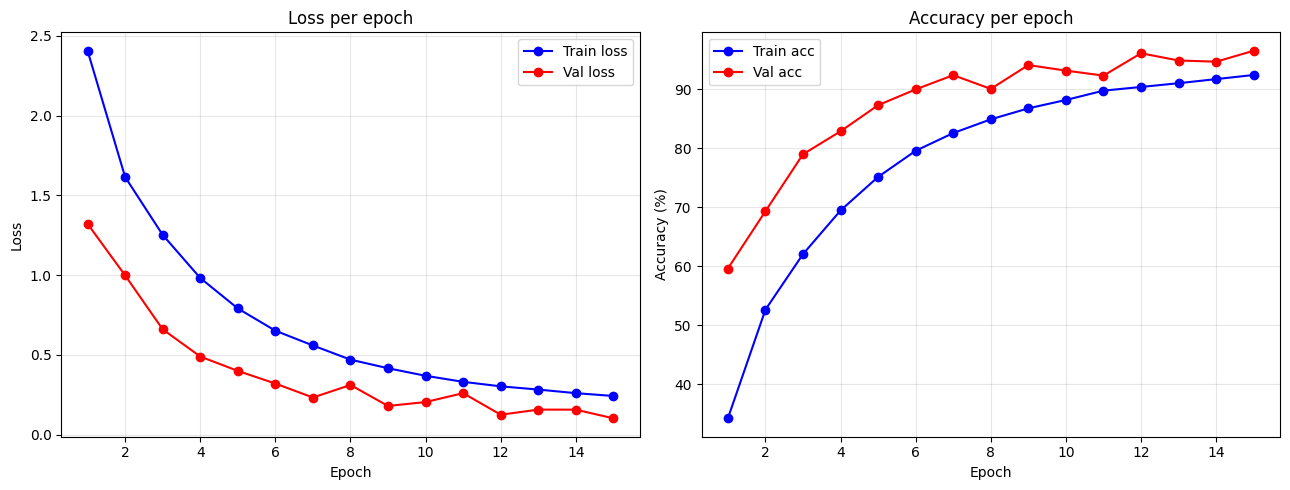

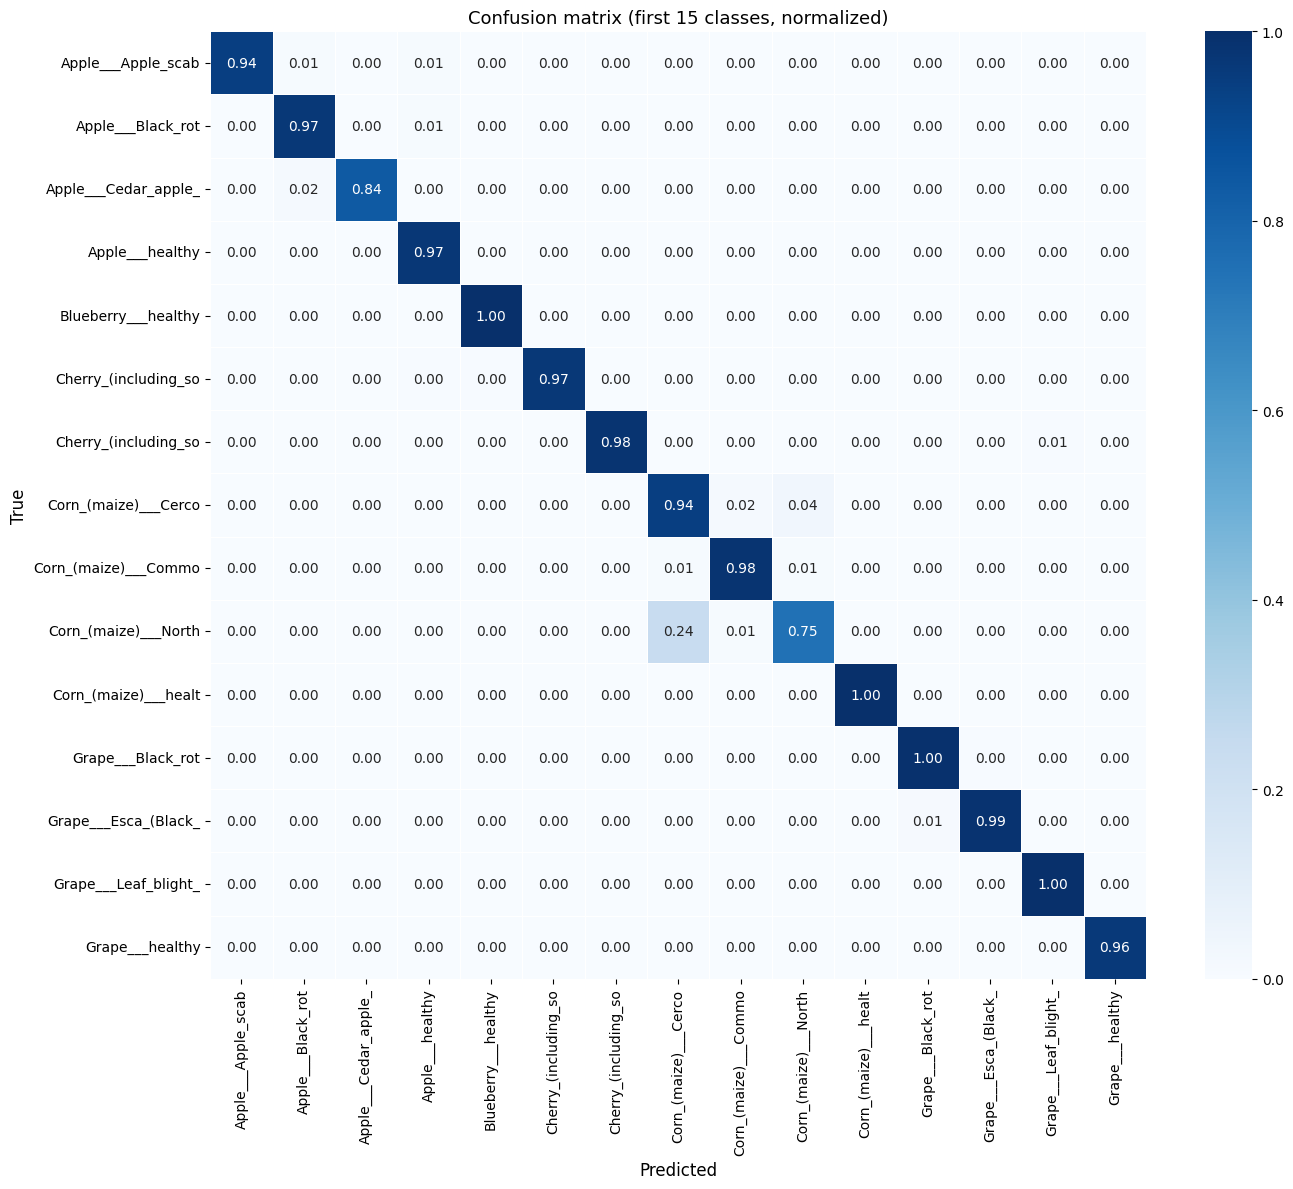


Classification report (top 10 worst classes):
  Potato___healthy                          F1: 0.462
  Corn_(maize)___Cercospora_leaf_spot Gray  F1: 0.779
  Tomato___Target_Spot                      F1: 0.835
  Corn_(maize)___Northern_Leaf_Blight       F1: 0.838
  Tomato___Early_blight                     F1: 0.851
  Tomato___healthy                          F1: 0.909
  Apple___Cedar_apple_rust                  F1: 0.911
  Tomato___Late_blight                      F1: 0.914
  Tomato___Spider_mites Two-spotted_spider  F1: 0.935
  Potato___Late_blight                      F1: 0.936


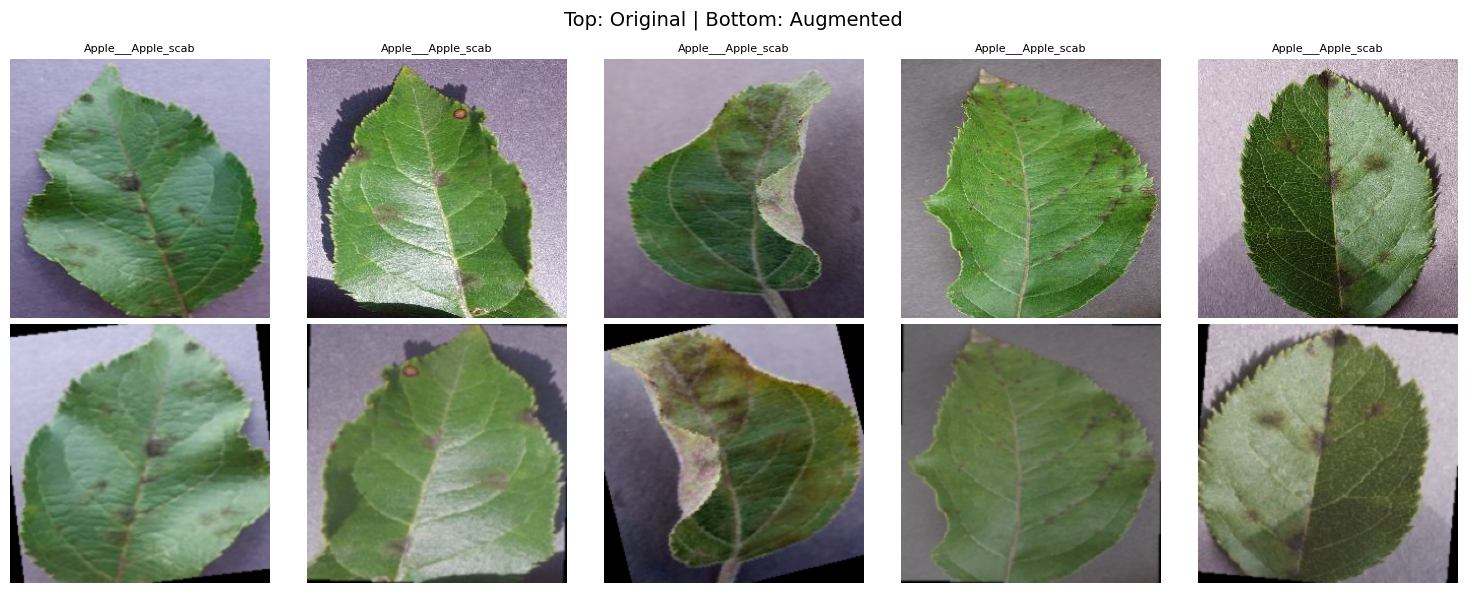

In [48]:
train_loader, val_loader, class_names, num_classes = load_data(CONFIG["data_dir"])

if os.path.exists(CONFIG["checkpoint"]):
    print("Checkpoint found → resuming training...")
    checkpoint = torch.load(CONFIG["checkpoint"])

    model = PlantDiseaseCNN(num_classes=num_classes).to(device)
    model.load_state_dict(checkpoint["model_state"])

    optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=1e-4)
    optimizer.load_state_dict(checkpoint["optim_state"])

    print(f"Resumed from epoch {checkpoint['epoch']}, best val acc: {checkpoint['val_acc']:.2f}%")

    history = train(
        model, train_loader, val_loader, num_classes,
        start_epoch      = checkpoint["epoch"] + 1,
        best_val_acc     = checkpoint["val_acc"],
        resume_optimizer = optimizer
    )

else:
    print("No checkpoint found → training from scratch...")
    model = PlantDiseaseCNN(num_classes=num_classes).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {total_params:,}")

    history = train(model, train_loader, val_loader, num_classes)

plot_history(history)
plot_confusion_matrix(model, val_loader, class_names)

data_dir = r"/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"
show_augmentations(data_dir, n_samples=5)